# Handwritten Persian Digit Generation using GANs

In this project, we will define two models to generate handwritten Persian digits from the "Hoda" dataset. The goal is to build a Generative Adversarial Network (GAN) that can generate high-quality, realistic handwritten Persian digits. 

The process will involve:

1. **Generator Model**: This model will generate fake handwritten digits from random noise vectors.
2. **Discriminator Model**: This model will distinguish between real and fake handwritten digits.

We will be using the **Hoda Dataset** for training our models. The Hoda dataset contains a large number of handwritten Persian digits, making it an excellent resource for training the GAN.

- Dataset Link: [Hoda Dataset](https://www.kaggle.com/datasets/invalizare/hoda-mat)

## Approach
- **Improved Generator**: The generator will consist of fully connected and deconvolutional layers, with batch normalization and activation functions to generate images.
- **Improved Discriminator**: The discriminator will consist of convolutional layers, batch normalization, and a fully connected output layer to classify the images as real or fake.

By the end of the project, we aim to train the GAN to generate high-quality Persian digits and evaluate its performance.


In [78]:
# General
import os
import struct
import numpy as np
import cv2
import matplotlib.pyplot as plt


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import Variable

# Function to read the Hoda dataset
from HodaDatasetReader import *



In [51]:
# Load the train dataset
train_images, train_labels = read_hoda_dataset('dataset/DigitDB/Train 60000.cdb', images_height=28, images_width=28, one_hot=False, reshape=False)

# Check the shapes of the data
print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")


Train images shape: (60000, 28, 28, 1)
Train labels shape: (60000,)


## Generator Model for Handwritten Digit Generation

In this code, we define a **Generator** model for generating synthetic images of handwritten digits. The generator uses a **fully connected layer** followed by several **deconvolutional layers** (also known as transposed convolutions) to progressively upscale a random noise vector into an image.

### Key components:
- **Fully connected layer**: Projects the noise vector (`z`) into a higher-dimensional space to form a base for image generation.
- **Deconvolutional layers**: These layers progressively increase the spatial dimensions of the feature maps, starting from a low resolution (7x7) and upsampling to the desired resolution (28x28).
- **Activation functions**: **ReLU** is used for hidden layers to introduce non-linearity, while **Tanh** is used in the output layer to scale the image pixel values between -1 and 1, suitable for image generation tasks.

The model is initialized with a default noise vector size of 100 (`z_dim=100`), and the output is a 28x28 grayscale image.

### Purpose:
The generator model learns to produce realistic handwritten digit images, using a noise vector as input. The output is intended to resemble real-world handwritten digits, useful for tasks like data augmentation and image generation.


In [52]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super(Generator, self).__init__()
        
        # Define the layers for the generator
        self.fc = nn.Linear(z_dim, 128 * 7 * 7)  # Fully connected layer
        self.deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # Upsampling: from 7x7 to 14x14
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)   # Upsampling: from 14x14 to 28x28
        # Updated last layer: no upsampling, just a refinement to produce 28x28 output
        self.deconv3 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1)    # Final output: remains 28x28
        
        # Activation functions
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()  # To scale the output between -1 and 1
        
    def forward(self, z):
        x = self.fc(z)                          # x shape: (batch_size, 128*7*7)
        x = x.view(x.size(0), 128, 7, 7)          # Reshape to: (batch_size, 128, 7, 7)
        x = self.relu(self.deconv1(x))            # Upsampled to: (batch_size, 64, 14, 14)
        x = self.relu(self.deconv2(x))            # Upsampled to: (batch_size, 32, 28, 28)
        x = self.tanh(self.deconv3(x))            # Final output remains: (batch_size, 1, 28, 28)
        return x

# Initialize the Generator
z_dim = 100  # Size of the noise vector
generator = Generator(z_dim=z_dim)

# Test with a dummy input
z = torch.randn(1, z_dim)  # Batch size 1
output = generator(z)
print("Output shape:", output.shape)  # Expected: torch.Size([1, 1, 28, 28])


Output shape: torch.Size([1, 1, 28, 28])


## Discriminator Model for Handwritten Digit Discrimination

In this code, we define a **Discriminator** model that classifies images as real or fake, based on the output of the **Generator**. The discriminator uses **convolutional layers** followed by a **fully connected layer** to analyze the input image and produce a probability score indicating whether the image is real or generated.

### Key components:
- **Convolutional layers**: These layers are responsible for extracting features from the input image. The input image size is 28x28 (single channel), and through two convolutional layers, the spatial resolution is reduced while the feature map depth increases.
- **Fully connected layer**: After extracting features, the output from the convolutional layers is flattened and passed through a fully connected layer for final classification.
- **Activation functions**: **Leaky ReLU** is used for hidden layers to allow for negative values and provide robustness against dying neurons, while **Sigmoid** is applied at the output layer to map the final result to a probability between 0 and 1.

The model classifies images as either "real" or "fake," where a value closer to 1 indicates a real image and a value closer to 0 indicates a fake image.

### Purpose:
The discriminator model plays a crucial role in the **Generative Adversarial Network (GAN)**, as it helps the generator improve by providing feedback on the authenticity of generated images. It is trained to distinguish between real images from the dataset and fake images produced by the generator.


In [53]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # Convolutional layers: Input image size 28x28 (single channel)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # Output: (batch, 32, 14, 14)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1) # Output: (batch, 64, 7, 7)
        
        # Fully connected layer for final prediction
        self.fc = nn.Linear(7 * 7 * 64, 1)
        
        # Activation functions
        self.leaky_relu = nn.LeakyReLU(0.2, inplace=True)
        self.sigmoid = nn.Sigmoid()  # Final output in the range [0, 1]
        
    def forward(self, x):
        x = self.leaky_relu(self.conv1(x))  # Output shape: (batch, 32, 14, 14)
        x = self.leaky_relu(self.conv2(x))  # Output shape: (batch, 64, 7, 7)
        x = x.view(x.size(0), -1)           # Flatten to vector: (batch, 7*7*64)
        x = self.fc(x)                      # Output: (batch, 1)
        x = self.sigmoid(x)                 # Map to range [0, 1]
        return x

# Instantiate the Discriminator model
discriminator = Discriminator()
print(discriminator)


Discriminator(
  (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (fc): Linear(in_features=3136, out_features=1, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.2, inplace=True)
  (sigmoid): Sigmoid()
)


# Setting up the GAN for Persian Handwritten Digits Generation

In this section, we are preparing the necessary components for training our **GAN** to generate Persian handwritten digits using the **Hoda dataset**.

### 1. Device Setup
We first determine if a GPU is available. If it is, we will use the GPU for training; otherwise, we fall back to using the CPU.

### 2. Data Preprocessing
The images are assumed to be loaded from the Hoda dataset as a NumPy array. We convert this array into a **PyTorch tensor** and rearrange its dimensions to match the format expected by PyTorch: `(batch, channels, height, width)`. Then, we scale the pixel values from the range `[0, 1]` to `[-1, 1]` since the **Generator** uses the **tanh** activation function, which produces outputs in the `[-1, 1]` range.

### 3. DataLoader Setup
We create a **TensorDataset** from the preprocessed training images and wrap it in a **DataLoader**. This allows us to efficiently load the dataset in batches and shuffle it during training.

### 4. Model Initialization
Here, we initialize the **Generator** and **Discriminator** models and move them to the appropriate device (GPU or CPU). These models will be responsible for generating the images and discriminating between real and fake images during training.

### 5. Loss Function and Optimizers
We use **Binary Cross Entropy (BCE) loss**, which is suitable for binary classification tasks like distinguishing between real and generated images. We then set up **Adam optimizers** for both the **Generator** and **Discriminator**, with a learning rate of `0.0002` and `beta1=0.5`, which are standard values for GANs.

Now, we're ready to move on to the training loop, where we will train both the **Discriminator** and **Generator** alternately to improve the performance of our GAN.


In [54]:
# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------
# Assume you have loaded train_images (numpy array with shape (60000, 28, 28, 1))
# from your hoda dataset using the provided HodaDatasetReader.py
# ---------------------------------------------------------------------

# Convert numpy array to torch tensor and rearrange dimensions to (batch, channels, height, width)
train_images_tensor = torch.tensor(train_images).permute(0, 3, 1, 2).float()

# Scale images from [0,1] to [-1,1] since Generator's output uses tanh activation
train_images_tensor = train_images_tensor * 2 - 1

# Create a TensorDataset and DataLoader for training
batch_size = 128
num_epochs = 50  
dataset = TensorDataset(train_images_tensor)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ---------------------------------------------------------------------
# Initialize the Generator and Discriminator models and move them to device
# ---------------------------------------------------------------------

# Assuming Generator and Discriminator classes are defined as earlier:
generator = Generator(z_dim=100).to(device)
discriminator = Discriminator().to(device)

# ---------------------------------------------------------------------
# Define loss function and optimizers
# ---------------------------------------------------------------------

# Binary Cross Entropy loss for both Generator and Discriminator
criterion = nn.BCELoss()

# Learning rate and beta for Adam optimizer
lr = 0.0002
beta1 = 0.5

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Training the GAN for Persian Handwritten Digits Generation

In this section, we define the training procedure for our **GAN** that generates Persian handwritten digits. The function `train_gan` handles the entire training process, which includes training both the **Discriminator** and **Generator** models alternately.

### 1. Function Parameters:
- **generator**: The generator model that produces fake images from random noise.
- **discriminator**: The discriminator model that distinguishes between real and fake images.
- **data_loader**: The DataLoader providing batches of real images from the dataset.
- **criterion**: The loss function (usually Binary Cross Entropy, `nn.BCELoss()`), which measures how well the discriminator performs.
- **optimizer_G**: The optimizer for the generator, typically Adam.
- **optimizer_D**: The optimizer for the discriminator, also typically Adam.
- **device**: The device to run the training on (either GPU or CPU).
- **num_epochs**: The number of times the entire dataset will be passed through the model.
- **z_dim**: The dimension of the noise vector (default is 100).
- **log_interval**: How often (in terms of batch count) to print the training statistics.

### 2. Training Process:
The training loop alternates between updating the **Discriminator** and **Generator**.

#### 2.1 Discriminator Training:
- **Real Images**: The discriminator is first trained on real images, where we compute the loss by comparing the discriminator’s output with real labels (1.0).
- **Fake Images**: Then, the discriminator is trained on fake images generated by the generator. We detach the fake images so that the gradients don't flow back into the generator during this step. The loss is calculated by comparing the output of the discriminator with fake labels (0.0).
- The total discriminator loss is the sum of the losses for real and fake images. We then update the **Discriminator's** weights using the optimizer.

#### 2.2 Generator Training:
- **Goal of the Generator**: The generator's goal is to fool the discriminator. Thus, during generator training, the discriminator's output for fake images is used to calculate the loss, but this time, we want the fake images to be classified as real (label 1.0).
- The generator’s weights are updated by backpropagating this loss.

### 3. Logging:
At regular intervals (`log_interval`), the function prints the current training statistics, including the losses for both the **Discriminator** and **Generator**.

By repeating this process over multiple epochs, the **Generator** learns to create more realistic images, and the **Discriminator** becomes better at distinguishing real from fake images.


In [55]:
def train_gan(generator, discriminator, data_loader, criterion, optimizer_G, optimizer_D, device, num_epochs, z_dim=100, log_interval=100):
    """
    Train a GAN with the provided generator and discriminator models.
    
    Parameters:
        generator (torch.nn.Module): The generator model.
        discriminator (torch.nn.Module): The discriminator model.
        data_loader (DataLoader): DataLoader for real images.
        criterion (torch.nn.Module): Loss function (e.g., nn.BCELoss()).
        optimizer_G (torch.optim.Optimizer): Optimizer for the generator.
        optimizer_D (torch.optim.Optimizer): Optimizer for the discriminator.
        device (torch.device): Device to run training on ('cuda' or 'cpu').
        num_epochs (int): Number of epochs to train.
        z_dim (int): Dimension of the noise vector (default is 100).
        log_interval (int): Interval (in batches) for logging training statistics.
    """
    # Set the models to training mode
    generator.train()
    discriminator.train()
    
    for epoch in range(num_epochs):
        for i, data in enumerate(data_loader, 0):
            # Get real images and move them to device
            real_images = data[0].to(device)
            current_batch_size = real_images.size(0)
            
            # Create labels for real and fake images
            real_labels = torch.full((current_batch_size, 1), 1.0, device=device)
            fake_labels = torch.full((current_batch_size, 1), 0.0, device=device)
            
            # ============================
            #  Train Discriminator
            # ============================
            
            # Zero the gradients for the discriminator
            discriminator.zero_grad()
            
            # Forward pass: Compute discriminator output on real images
            output_real = discriminator(real_images)
            loss_D_real = criterion(output_real, real_labels)
            loss_D_real.backward()
            
            # Generate fake images using the generator
            noise = torch.randn(current_batch_size, z_dim, device=device)
            fake_images = generator(noise)
            
            # Forward pass: Compute discriminator output on fake images
            # Detach fake_images so that gradients are not computed for the generator here
            output_fake = discriminator(fake_images.detach())
            loss_D_fake = criterion(output_fake, fake_labels)
            loss_D_fake.backward()
            
            # Total discriminator loss
            loss_D = loss_D_real + loss_D_fake
            optimizer_D.step()
            
            # ============================
            #  Train Generator
            # ============================
            
            # Zero the gradients for the generator
            generator.zero_grad()
            
            # Generator tries to fool the discriminator, so we use real labels for fake images
            output_fake_for_G = discriminator(fake_images)
            loss_G = criterion(output_fake_for_G, real_labels)
            loss_G.backward()
            optimizer_G.step()
            
            # Print training statistics every log_interval batches
            if i % log_interval == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}] Batch {i}/{len(data_loader)} ' +
                      f'Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}')


In [56]:
# Example usage:
# Assume that you have defined `generator`, `discriminator`, `data_loader`, `criterion`, 
# `optimizer_G`, `optimizer_D`, and `device` already.
train_gan(generator, discriminator, data_loader, criterion, optimizer_G, optimizer_D, device, num_epochs, z_dim=z_dim, log_interval=100)
torch.save(generator.state_dict(), 'generator_weights.pth')

Epoch [1/50] Batch 0/469 Loss D: 1.4067, Loss G: 0.7180
Epoch [1/50] Batch 100/469 Loss D: 1.0416, Loss G: 1.1326
Epoch [1/50] Batch 200/469 Loss D: 0.9749, Loss G: 1.0271
Epoch [1/50] Batch 300/469 Loss D: 1.1166, Loss G: 1.1053
Epoch [1/50] Batch 400/469 Loss D: 1.0054, Loss G: 0.8819
Epoch [2/50] Batch 0/469 Loss D: 1.0392, Loss G: 1.2188
Epoch [2/50] Batch 100/469 Loss D: 1.1959, Loss G: 0.5294
Epoch [2/50] Batch 200/469 Loss D: 0.9886, Loss G: 1.0181
Epoch [2/50] Batch 300/469 Loss D: 1.0134, Loss G: 0.9082
Epoch [2/50] Batch 400/469 Loss D: 1.0129, Loss G: 1.2020
Epoch [3/50] Batch 0/469 Loss D: 0.9891, Loss G: 0.7916
Epoch [3/50] Batch 100/469 Loss D: 0.9575, Loss G: 1.1725
Epoch [3/50] Batch 200/469 Loss D: 0.9703, Loss G: 1.5700
Epoch [3/50] Batch 300/469 Loss D: 0.9630, Loss G: 1.0421
Epoch [3/50] Batch 400/469 Loss D: 0.9133, Loss G: 1.0599
Epoch [4/50] Batch 0/469 Loss D: 0.9455, Loss G: 0.9847
Epoch [4/50] Batch 100/469 Loss D: 0.9180, Loss G: 0.9896
Epoch [4/50] Batch 200

# Generating and Plotting Fake Images from the Generator

The function `generate_and_plot_images` generates fake images using the trained **Generator** model and displays them in a grid format. This is useful to visually assess how well the generator is producing images after training.

### 1. Function Parameters:
- **generator**: The trained generator model, which will be used to generate fake images.
- **num_images**: The number of fake images to generate and display.
- **z_dim**: The dimensionality of the noise vector that serves as input to the generator (default is 100).
- **device**: The device to run the generator on (either 'cpu' or 'cuda').

### 2. Function Process:
- **Evaluation Mode**: The generator is set to evaluation mode (`eval()`), which disables layers like dropout and batch normalization that behave differently during training.
- **Noise Vector Generation**: A batch of random noise vectors (`torch.randn()`) is created as input to the generator.
- **Fake Image Generation**: The generator creates fake images by passing the noise through it. The `torch.no_grad()` context is used to ensure that no gradients are calculated during this operation (since we don't need to backpropagate for generating images).
- **Image Scaling**: The generated images are scaled from the range [-1, 1] (output from `tanh`) to [0, 1] for visualization.
- **Grid Plotting**: The function calculates a square grid size based on the number of images and plots the images in a grid format using `matplotlib`.

### 3. Example Usage:
The function is called with `generate_and_plot_images(generator, 16)`, which generates 16 fake images and displays them in a grid.

This function is helpful for visually inspecting how well the **Generator** has learned to create realistic images after being trained.


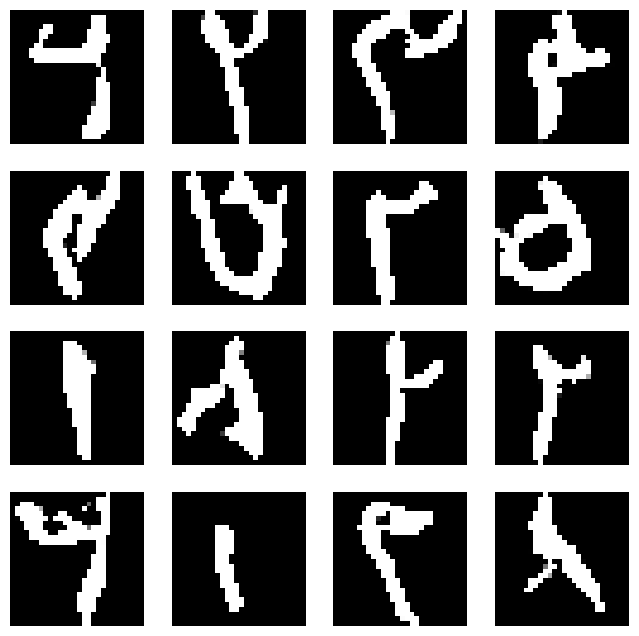

In [57]:
def generate_and_plot_images(generator, num_images, z_dim=100, device='cuda'):
    """
    Generates fake images using the generator and plots them in a grid.
    
    Parameters:
    - generator: The trained generator model.
    - num_images: The number of fake images to generate.
    - z_dim: The dimensionality of the noise vector (default is 100).
    - device: The device to run the generator on ('cpu' or 'cuda').
    """
    # Set the generator to evaluation mode
    generator.eval()
    
    # Generate random noise vectors
    noise = torch.randn(num_images, z_dim, device=device)  # Generate noise
    
    # Generate fake images using the generator
    with torch.no_grad():
        fake_images = generator(noise).detach().cpu()
    
    # Scale images from [-1, 1] to [0, 1]
    fake_images = (fake_images + 1) / 2
    
    # Plot the generated images in a grid
    grid_size = int(num_images ** 0.5)  # Try to make the grid square-shaped
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(fake_images[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.show()

# Example usage
generate_and_plot_images(generator, 16)


In [58]:
# Improved Generator with Batch Normalization
class ImprovedGenerator(nn.Module):
    def __init__(self, z_dim=100):
        super(ImprovedGenerator, self).__init__()
        # Fully connected layer to project z_dim to 128*7*7 features
        self.fc = nn.Linear(z_dim, 128 * 7 * 7)  # Project noise vector
        self.bn0 = nn.BatchNorm1d(128 * 7 * 7)    # BatchNorm for fc output
        
        # First deconvolution: from 7x7 to 14x14
        self.deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64)             # BatchNorm after deconv1
        
        # Second deconvolution: from 14x14 to 28x28
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(32)             # BatchNorm after deconv2
        
        # Final deconvolution: refine output to maintain 28x28 dimensions
        self.deconv3 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1)
        
        # Activation functions
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()  # Output scaled between -1 and 1
        
    def forward(self, z):
        # Project and reshape noise vector
        x = self.fc(z)
        x = self.bn0(x)
        x = self.relu(x)
        x = x.view(x.size(0), 128, 7, 7)  # Reshape to (batch, 128, 7, 7)
        
        # Upsampling with batch normalization
        x = self.relu(self.bn1(self.deconv1(x)))  # Output: (batch, 64, 14, 14)
        x = self.relu(self.bn2(self.deconv2(x)))  # Output: (batch, 32, 28, 28)
        x = self.tanh(self.deconv3(x))            # Final output: (batch, 1, 28, 28)
        return x


z_dim = 100
improved_generator = ImprovedGenerator(z_dim=z_dim)
improved_generator.eval()  # Set the model to evaluation mode

dummy_noise = torch.randn(1, z_dim)  # Batch size 1
print("Improved Generator output shape:", improved_generator(dummy_noise).shape)  # Expected: (1, 1, 28, 28)

Improved Generator output shape: torch.Size([1, 1, 28, 28])


# Improved Generator with Batch Normalization

The `ImprovedGenerator` class defines a deep convolutional generator network with **batch normalization** and **deconvolution layers** to generate high-quality images. Batch normalization helps improve training stability and performance by normalizing the activations in each layer, reducing the effects of internal covariate shift.

### 1. Class Structure:
- **Fully Connected Layer (`fc`)**: Projects the input noise vector (`z_dim`) into a tensor of size `128 * 7 * 7`, which is then reshaped to match the shape of intermediate feature maps.
- **Batch Normalization (`bn0`)**: Applied to the output of the fully connected layer to stabilize the learning process.
- **Deconvolution Layers**:
  - **First Deconvolution (`deconv1`)**: Upsamples the feature map from size `7x7` to `14x14`.
  - **Second Deconvolution (`deconv2`)**: Further upsamples the feature map from `14x14` to `28x28`.
  - **Final Deconvolution (`deconv3`)**: Produces the final image with shape `28x28` in a single channel (grayscale).
- **Activation Functions**: 
  - **ReLU**: Used after the fully connected layer and the deconvolution layers to introduce non-linearity.
  - **Tanh**: Applied to the final output to scale the pixel values between `-1` and `1`, which matches the output range expected by the discriminator.

### 2. Forward Pass:
- The input noise vector (`z`) is passed through the fully connected layer, reshaped, and then upsampled using deconvolution layers with batch normalization. 
- The final output is a `28x28` grayscale image (batch size `1`).

### 3. Example Usage:
```python
z_dim = 100
improved_generator = ImprovedGenerator(z_dim=z_dim)
improved_generator.eval()  # Set the model to evaluation mode

dummy_noise = torch.randn(1, z_dim)  # Batch size 1
print("Improved Generator output shape:", improved_generator(dummy_noise).shape)  # Expected: (1, 1, 28, 28)


# Improved Discriminator with Batch Normalization

The `ImprovedDiscriminator` class defines a convolutional neural network (CNN) used to distinguish between real and fake images. This discriminator model uses **batch normalization** and **leaky ReLU activations** for improved stability and performance.

### 1. Class Structure:
- **Convolutional Layers**:
  - **First Convolution (`conv1`)**: Extracts features from the input image. It takes a `1x28x28` image and produces a feature map of size `(batch, 32, 14, 14)`.
  - **Second Convolution (`conv2`)**: Extracts more abstract features, producing a feature map of size `(batch, 64, 7, 7)`.
- **Batch Normalization**:
  - **After `conv1` and `conv2`**, batch normalization is applied to stabilize training by normalizing the activations within each mini-batch.
- **Fully Connected Layer (`fc`)**: Flattens the feature map and passes it through a fully connected layer to make the final binary decision (real or fake).
- **Activation Functions**:
  - **Leaky ReLU**: Used after each convolutional layer with a slope of 0.2 to allow for small negative values, which helps mitigate the "dying ReLU" problem.
  - **Sigmoid**: Applied to the final output to map it between `[0, 1]`, which represents the probability of an image being real.

### 2. Forward Pass:
- The input image (`x`) is passed through the convolutional layers, where it is progressively downsampled and feature maps are extracted. Batch normalization is applied after each convolution to stabilize training.
- The feature map is then flattened and passed through the fully connected layer to make a decision on whether the image is real or fake.

### 3. Example Usage:
```python
# Instantiate the Discriminator model
improved_discriminator = ImprovedDiscriminator()
print(improved_discriminator)


In [59]:
# Improved Discriminator with Batch Normalization
class ImprovedDiscriminator(nn.Module):
    def __init__(self):
        super(ImprovedDiscriminator, self).__init__()
        # Convolutional layers for feature extraction
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # Output: (batch, 32, 14, 14)
        self.bn1 = nn.BatchNorm2d(32)  # BatchNorm after conv1
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # Output: (batch, 64, 7, 7)
        self.bn2 = nn.BatchNorm2d(64)  # BatchNorm after conv2
        
        # Fully connected layer for final discrimination
        self.fc = nn.Linear(7 * 7 * 64, 1)
        
        # Activation functions
        self.leaky_relu = nn.LeakyReLU(0.2, inplace=True)
        self.sigmoid = nn.Sigmoid()  # Map output to [0, 1]
        
    def forward(self, x):
        # Feature extraction with convolution, batch normalization, and activation
        x = self.leaky_relu(self.bn1(self.conv1(x)))  # Shape: (batch, 32, 14, 14)
        x = self.leaky_relu(self.bn2(self.conv2(x)))    # Shape: (batch, 64, 7, 7)
        x = x.view(x.size(0), -1)                       # Flatten to (batch, 7*7*64)
        x = self.fc(x)                                # Fully connected layer
        x = self.sigmoid(x)                           # Output probability
        return x

# Instantiate the Discriminator model
improved_discriminator = ImprovedDiscriminator()
print(improved_discriminator)

ImprovedDiscriminator(
  (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=3136, out_features=1, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.2, inplace=True)
  (sigmoid): Sigmoid()
)


In [64]:
dataset = TensorDataset(train_images_tensor)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Transfer the models to the device
improved_generator = ImprovedGenerator(z_dim=z_dim).to(device)
improved_discriminator = ImprovedDiscriminator().to(device)

criterion = nn.BCELoss()

# Define new optimizers for the new models
optimizer_G = optim.Adam(improved_generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(improved_discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Clear any remaining gradients from previous models
torch.cuda.empty_cache()  # If using GPU, this helps free up memory

# Train the improved generator and discriminator
train_gan(improved_generator, improved_discriminator, data_loader, 
          criterion, optimizer_G, optimizer_D, device, num_epochs, z_dim=z_dim, log_interval=100)


Epoch [1/50] Batch 0/469 Loss D: 1.4923, Loss G: 0.8059
Epoch [1/50] Batch 100/469 Loss D: 0.9845, Loss G: 1.0792
Epoch [1/50] Batch 200/469 Loss D: 0.8177, Loss G: 1.2379
Epoch [1/50] Batch 300/469 Loss D: 0.6492, Loss G: 1.5650
Epoch [1/50] Batch 400/469 Loss D: 0.4988, Loss G: 2.0729
Epoch [2/50] Batch 0/469 Loss D: 0.4412, Loss G: 2.0679
Epoch [2/50] Batch 100/469 Loss D: 0.5073, Loss G: 2.6705
Epoch [2/50] Batch 200/469 Loss D: 0.4185, Loss G: 2.1124
Epoch [2/50] Batch 300/469 Loss D: 0.4335, Loss G: 1.5913
Epoch [2/50] Batch 400/469 Loss D: 0.3488, Loss G: 2.4748
Epoch [3/50] Batch 0/469 Loss D: 0.3357, Loss G: 2.2507
Epoch [3/50] Batch 100/469 Loss D: 0.3604, Loss G: 2.3642
Epoch [3/50] Batch 200/469 Loss D: 0.2858, Loss G: 2.7061
Epoch [3/50] Batch 300/469 Loss D: 0.5443, Loss G: 4.1683
Epoch [3/50] Batch 400/469 Loss D: 0.3112, Loss G: 2.6138
Epoch [4/50] Batch 0/469 Loss D: 0.2819, Loss G: 2.6550
Epoch [4/50] Batch 100/469 Loss D: 0.3458, Loss G: 1.9864
Epoch [4/50] Batch 200

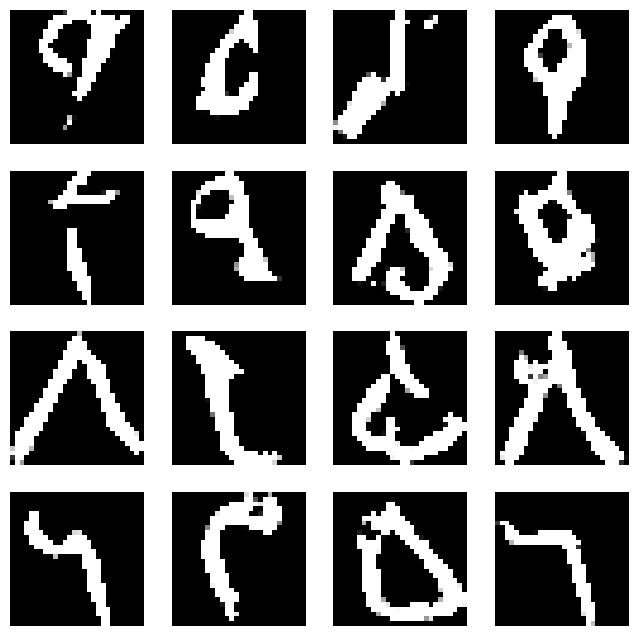

In [76]:
generate_and_plot_images(improved_generator, 16)


In [66]:
torch.save(improved_generator.state_dict(), 'improved_generator_weights.pth')